In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

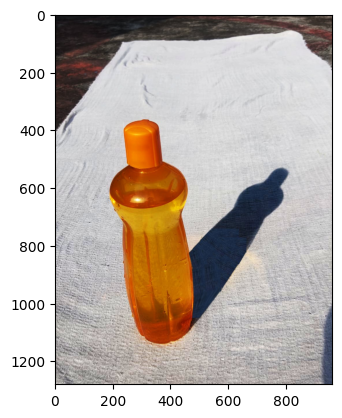

In [29]:
img=cv2.imread("./new.jpg",1)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Classical Shadow Detection Pipeline

## Overview
Shadow detection is a fundamental challenge in computer vision. Shadows typically exhibit:
- **Lower intensity/brightness** compared to surrounding areas
- **Similar chromaticity** (color hue) to the shadowed surface
- **Soft or sharp boundaries** depending on the light source

## Step-by-Step Pipeline

### 1. **Color Space Conversion**
Convert RGB to HSV (Hue, Saturation, Value) or Lab color space:
- **HSV**: Separates brightness (V-channel) from color information
- **Lab**: L-channel represents lightness, independent of color

### 2. **Identify High-Contrast Objects**
- Use edge detection (Canny, Sobel) or color-based segmentation
- Apply adaptive thresholding on saturation and value channels
- Objects typically have high saturation and distinct edges

### 3. **Shadow Detection Strategy**
Shadows are characterized by:
- **Low V-channel values** (in HSV)
- **Low L-channel values** (in Lab)
- **Preserved or slightly reduced hue** (H-channel)
- **Lower saturation** than the object

### 4. **Morphological Operations**
- Remove noise with opening/closing operations
- Fill holes and smooth boundaries
- Connect fragmented shadow regions

### 5. **Refinement**
- Use gradient analysis to detect shadow boundaries
- Apply connected component analysis
- Filter by geometric constraints (size, shape, proximity to objects)

## Implementation: Complete Shadow Detection Pipeline

In [30]:
def detect_objects_and_shadows(image_path, visualize=True):
    """
    Complete pipeline for detecting high-contrast objects and their shadows
    using classical computer vision techniques.
    
    Parameters:
    -----------
    image_path : str
        Path to the input image
    visualize : bool
        Whether to display intermediate results
    
    Returns:
    --------
    object_mask : numpy array
        Binary mask of detected objects
    shadow_mask : numpy array
        Binary mask of detected shadows
    """
    
    # Step 1: Load image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image from {image_path}")
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width = img.shape[:2]
    
    # Step 2: Convert to multiple color spaces
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    
    # Extract channels
    h, s, v = cv2.split(hsv)
    l, a, b = cv2.split(lab)
    
    # Step 3: Detect High-Contrast Objects
    # Objects typically have high saturation and distinct edges
    
    # Method 1: Edge-based detection
    edges = cv2.Canny(img, 50, 150)
    
    # Method 2: Saturation-based detection
    # High saturation indicates colorful objects
    _, sat_thresh = cv2.threshold(s, 50, 255, cv2.THRESH_BINARY)
    
    # Method 3: Adaptive thresholding on value channel
    v_adapt = cv2.adaptiveThreshold(v, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                     cv2.THRESH_BINARY, 15, -2)
    
    # Combine object detection methods
    object_mask = cv2.bitwise_or(sat_thresh, v_adapt)
    
    # Morphological operations to clean up object mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    object_mask = cv2.morphologyEx(object_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    object_mask = cv2.morphologyEx(object_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    
    # Step 4: Detect Shadows
    # Shadows have low brightness but preserved hue
    
    # Method 1: Low value in HSV (dark regions)
    _, v_shadow = cv2.threshold(v, 100, 255, cv2.THRESH_BINARY_INV)
    
    # Method 2: Low lightness in Lab
    _, l_shadow = cv2.threshold(l, 100, 255, cv2.THRESH_BINARY_INV)
    
    # Method 3: Ratio-based approach (compare with normalized image)
    # Shadows appear darker than expected
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (15, 15), 0)
    
    # Create ratio image
    ratio = np.zeros_like(gray, dtype=np.float32)
    mask = blur > 10
    ratio[mask] = gray[mask].astype(np.float32) / blur[mask].astype(np.float32)
    
    # Shadows will have low ratio values
    ratio_normalized = (ratio * 255).astype(np.uint8)
    _, ratio_shadow = cv2.threshold(ratio_normalized, 180, 255, cv2.THRESH_BINARY_INV)
    
    # Combine shadow detection methods
    shadow_mask = cv2.bitwise_and(v_shadow, l_shadow)
    shadow_mask = cv2.bitwise_or(shadow_mask, ratio_shadow)
    
    # Refine shadow mask
    # Remove shadows that overlap with objects (objects are not shadows)
    shadow_mask = cv2.bitwise_and(shadow_mask, cv2.bitwise_not(object_mask))
    
    # Morphological operations to clean up shadow mask
    kernel_shadow = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    shadow_mask = cv2.morphologyEx(shadow_mask, cv2.MORPH_OPEN, kernel_shadow, iterations=1)
    shadow_mask = cv2.morphologyEx(shadow_mask, cv2.MORPH_CLOSE, kernel_shadow, iterations=2)
    
    # Step 5: Post-processing - Remove small regions
    # Connected component analysis
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(shadow_mask, connectivity=8)
    
    # Filter by area (remove small noise)
    min_shadow_area = (height * width) * 0.001  # Minimum 0.1% of image
    shadow_mask_filtered = np.zeros_like(shadow_mask)
    
    for i in range(1, num_labels):  # Skip background (label 0)
        area = stats[i, cv2.CC_STAT_AREA]
        if area > min_shadow_area:
            shadow_mask_filtered[labels == i] = 255
    
    # Visualization
    if visualize:
        fig, axes = plt.subplots(3, 3, figsize=(15, 15))
        
        axes[0, 0].imshow(img_rgb)
        axes[0, 0].set_title('Original Image')
        axes[0, 0].axis('off')
        
        axes[0, 1].imshow(hsv)
        axes[0, 1].set_title('HSV Image')
        axes[0, 1].axis('off')
        
        axes[0, 2].imshow(v, cmap='gray')
        axes[0, 2].set_title('V Channel (Brightness)')
        axes[0, 2].axis('off')
        
        axes[1, 0].imshow(s, cmap='gray')
        axes[1, 0].set_title('S Channel (Saturation)')
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(l, cmap='gray')
        axes[1, 1].set_title('L Channel (Lightness)')
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(object_mask, cmap='gray')
        axes[1, 2].set_title('Detected Objects')
        axes[1, 2].axis('off')
        
        axes[2, 0].imshow(shadow_mask, cmap='gray')
        axes[2, 0].set_title('Raw Shadow Mask')
        axes[2, 0].axis('off')
        
        axes[2, 1].imshow(shadow_mask_filtered, cmap='gray')
        axes[2, 1].set_title('Filtered Shadow Mask')
        axes[2, 1].axis('off')
        
        # Overlay shadows on original image
        overlay = img_rgb.copy()
        overlay[shadow_mask_filtered == 255] = [255, 0, 0]  # Red for shadows
        result = cv2.addWeighted(img_rgb, 0.7, overlay, 0.3, 0)
        
        axes[2, 2].imshow(result)
        axes[2, 2].set_title('Shadow Overlay (Red)')
        axes[2, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return object_mask, shadow_mask_filtered

## Usage Example

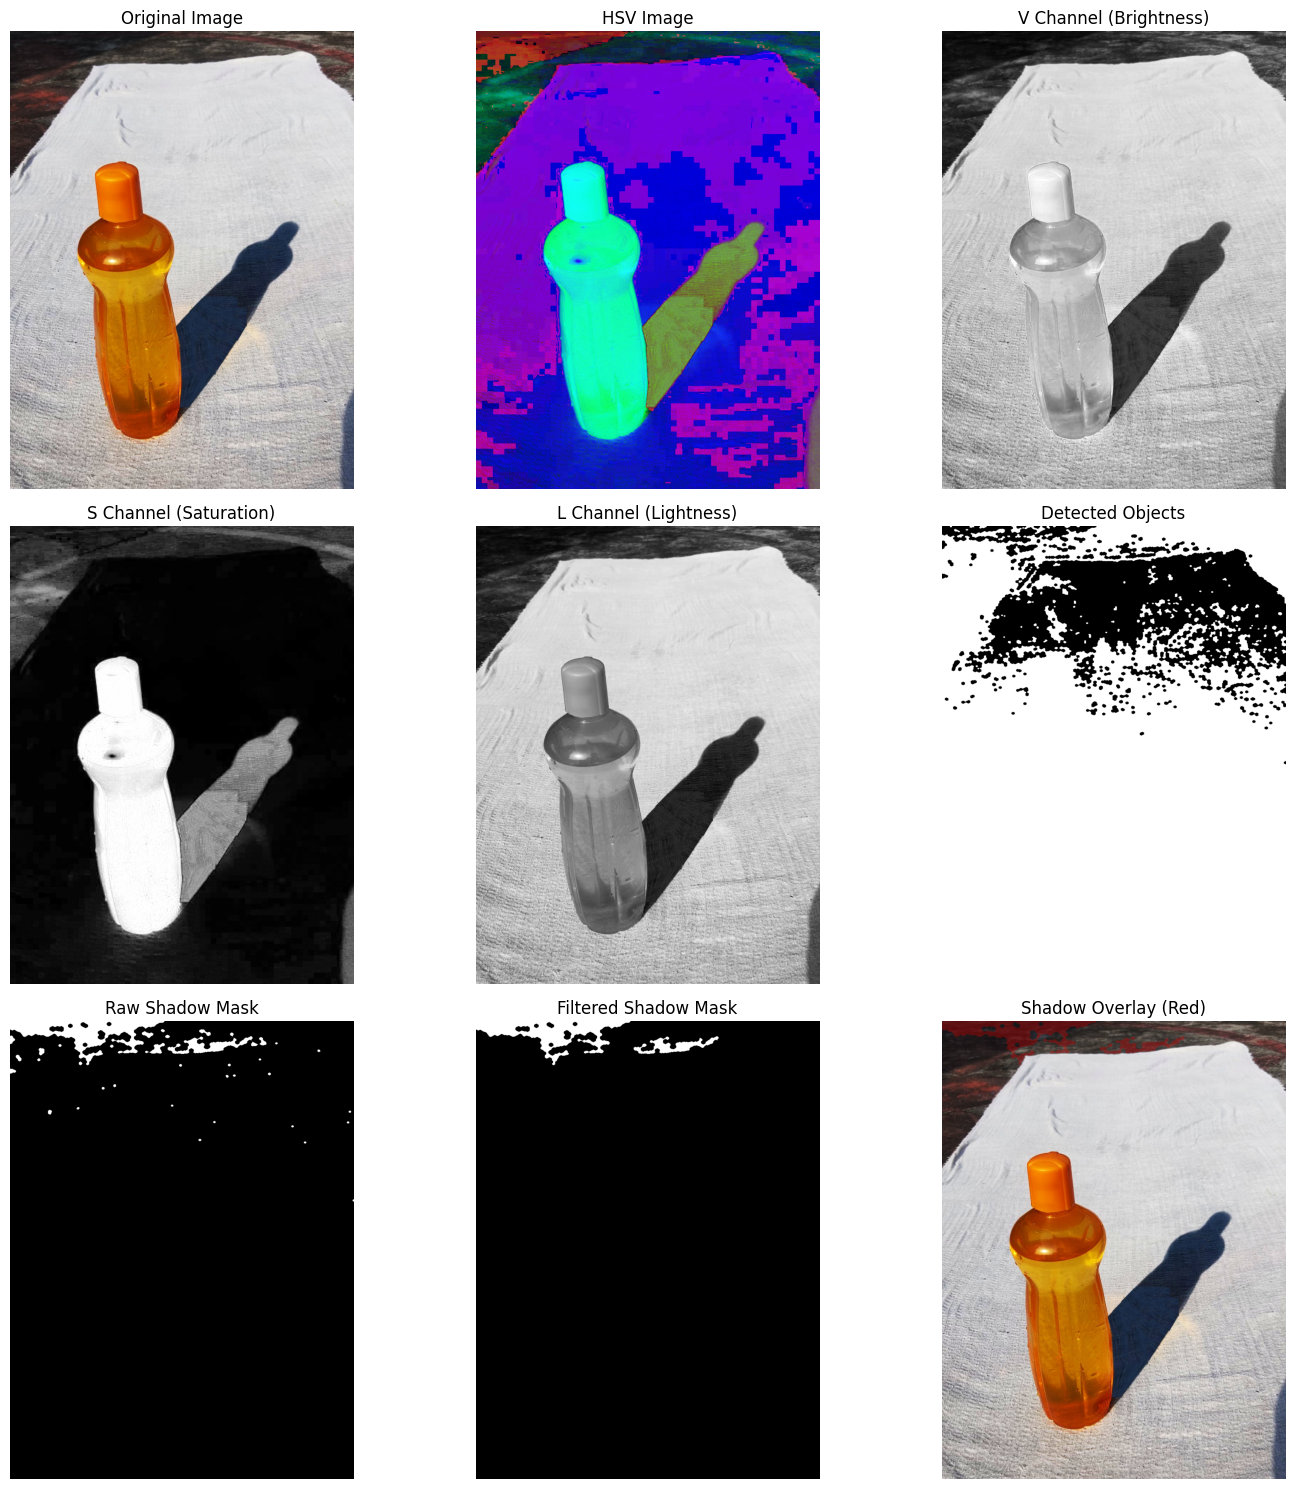

In [31]:
# Run the shadow detection pipeline on your test image
object_mask, shadow_mask = detect_objects_and_shadows("./new.jpg", visualize=True)

## Advanced: Fine-Tuned Shadow Detection with Parameter Control

In [32]:
def detect_shadows_tunable(image_path, 
                           v_threshold=100,        # HSV value threshold
                           l_threshold=100,        # Lab lightness threshold
                           ratio_threshold=180,    # Brightness ratio threshold
                           sat_threshold=50,       # Saturation threshold for objects
                           min_area_percent=0.001, # Minimum shadow area (% of image)
                           morph_kernel_size=7):   # Morphological kernel size
    """
    Tunable version of shadow detection with exposed parameters.
    
    Parameters:
    -----------
    v_threshold : int (0-255)
        Lower values detect more shadows (more sensitive)
    l_threshold : int (0-255)
        Lower values detect more shadows
    ratio_threshold : int (0-255)
        Higher values detect more shadows
    sat_threshold : int (0-255)
        Lower values include more regions as objects
    min_area_percent : float
        Minimum shadow area as percentage of total image (0.001 = 0.1%)
    morph_kernel_size : int (odd number)
        Size of morphological operations kernel
    
    Returns:
    --------
    shadow_mask : numpy array
        Binary mask of detected shadows
    stats : dict
        Dictionary containing detection statistics
    """
    
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width = img.shape[:2]
    
    # Color space conversions
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    h, s, v = cv2.split(hsv)
    l, a, b = cv2.split(lab)
    
    # Detect objects
    _, sat_thresh = cv2.threshold(s, sat_threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    object_mask = cv2.morphologyEx(sat_thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Detect shadows using multiple criteria
    _, v_shadow = cv2.threshold(v, v_threshold, 255, cv2.THRESH_BINARY_INV)
    _, l_shadow = cv2.threshold(l, l_threshold, 255, cv2.THRESH_BINARY_INV)
    
    # Ratio-based detection
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (15, 15), 0)
    ratio = np.zeros_like(gray, dtype=np.float32)
    mask = blur > 10
    ratio[mask] = gray[mask].astype(np.float32) / blur[mask].astype(np.float32)
    ratio_normalized = (ratio * 255).astype(np.uint8)
    _, ratio_shadow = cv2.threshold(ratio_normalized, ratio_threshold, 255, cv2.THRESH_BINARY_INV)
    
    # Combine shadow criteria
    shadow_mask = cv2.bitwise_and(v_shadow, l_shadow)
    shadow_mask = cv2.bitwise_or(shadow_mask, ratio_shadow)
    shadow_mask = cv2.bitwise_and(shadow_mask, cv2.bitwise_not(object_mask))
    
    # Morphological refinement
    kernel_shadow = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))
    shadow_mask = cv2.morphologyEx(shadow_mask, cv2.MORPH_OPEN, kernel_shadow, iterations=1)
    shadow_mask = cv2.morphologyEx(shadow_mask, cv2.MORPH_CLOSE, kernel_shadow, iterations=2)
    
    # Filter by area
    num_labels, labels, stats_cc, centroids = cv2.connectedComponentsWithStats(shadow_mask, connectivity=8)
    min_shadow_area = (height * width) * min_area_percent
    shadow_mask_filtered = np.zeros_like(shadow_mask)
    
    shadow_regions = []
    for i in range(1, num_labels):
        area = stats_cc[i, cv2.CC_STAT_AREA]
        if area > min_shadow_area:
            shadow_mask_filtered[labels == i] = 255
            shadow_regions.append({
                'label': i,
                'area': area,
                'centroid': centroids[i],
                'bbox': (stats_cc[i, cv2.CC_STAT_LEFT], 
                        stats_cc[i, cv2.CC_STAT_TOP],
                        stats_cc[i, cv2.CC_STAT_WIDTH], 
                        stats_cc[i, cv2.CC_STAT_HEIGHT])
            })
    
    # Calculate statistics
    total_pixels = height * width
    shadow_pixels = np.sum(shadow_mask_filtered == 255)
    stats = {
        'total_pixels': total_pixels,
        'shadow_pixels': shadow_pixels,
        'shadow_percentage': (shadow_pixels / total_pixels) * 100,
        'num_shadow_regions': len(shadow_regions),
        'shadow_regions': shadow_regions
    }
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(v_shadow, cmap='gray')
    axes[0, 1].set_title(f'V-channel Shadow (thresh={v_threshold})')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(l_shadow, cmap='gray')
    axes[0, 2].set_title(f'L-channel Shadow (thresh={l_threshold})')
    axes[0, 2].axis('off')
    
    axes[1, 0].imshow(ratio_shadow, cmap='gray')
    axes[1, 0].set_title(f'Ratio Shadow (thresh={ratio_threshold})')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(shadow_mask_filtered, cmap='gray')
    axes[1, 1].set_title(f'Final Shadow Mask ({stats["num_shadow_regions"]} regions)')
    axes[1, 1].axis('off')
    
    # Overlay
    overlay = img_rgb.copy()
    overlay[shadow_mask_filtered == 255] = [255, 0, 0]
    result = cv2.addWeighted(img_rgb, 0.7, overlay, 0.3, 0)
    axes[1, 2].imshow(result)
    axes[1, 2].set_title(f'Shadow Overlay ({stats["shadow_percentage"]:.2f}% of image)')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*50}")
    print(f"SHADOW DETECTION STATISTICS")
    print(f"{'='*50}")
    print(f"Total pixels: {stats['total_pixels']:,}")
    print(f"Shadow pixels: {stats['shadow_pixels']:,}")
    print(f"Shadow coverage: {stats['shadow_percentage']:.2f}%")
    print(f"Number of shadow regions: {stats['num_shadow_regions']}")
    print(f"{'='*50}\n")
    
    return shadow_mask_filtered, stats

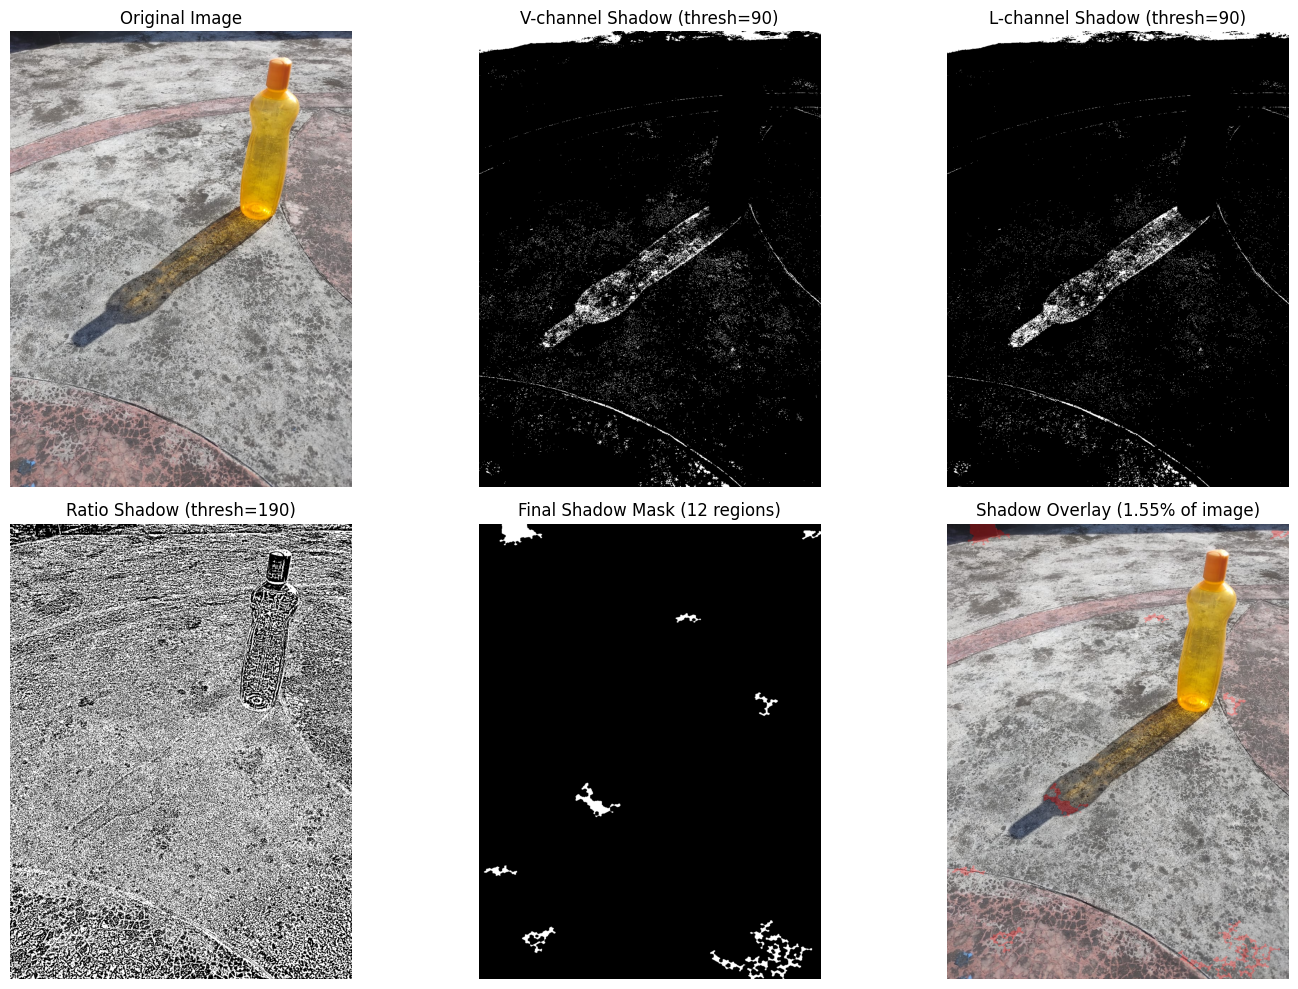


SHADOW DETECTION STATISTICS
Total pixels: 1,228,800
Shadow pixels: 19,100
Shadow coverage: 1.55%
Number of shadow regions: 12



In [33]:
# Example: Tune parameters for your specific image
# Experiment with these values to optimize shadow detection

shadow_mask, stats = detect_shadows_tunable(
    "./test35.jpg",
    v_threshold=90,          # Lower = more sensitive (try 70-120)
    l_threshold=90,          # Lower = more sensitive (try 70-120)
    ratio_threshold=190,     # Higher = more sensitive (try 170-200)
    sat_threshold=40,        # Lower = more objects detected (try 30-70)
    min_area_percent=0.0005, # Minimum shadow size (try 0.0001-0.01)
    morph_kernel_size=5      # Smoothing (try 3, 5, 7, 9)
)

## Alternative Method: Gradient-Based Shadow Boundary Detection

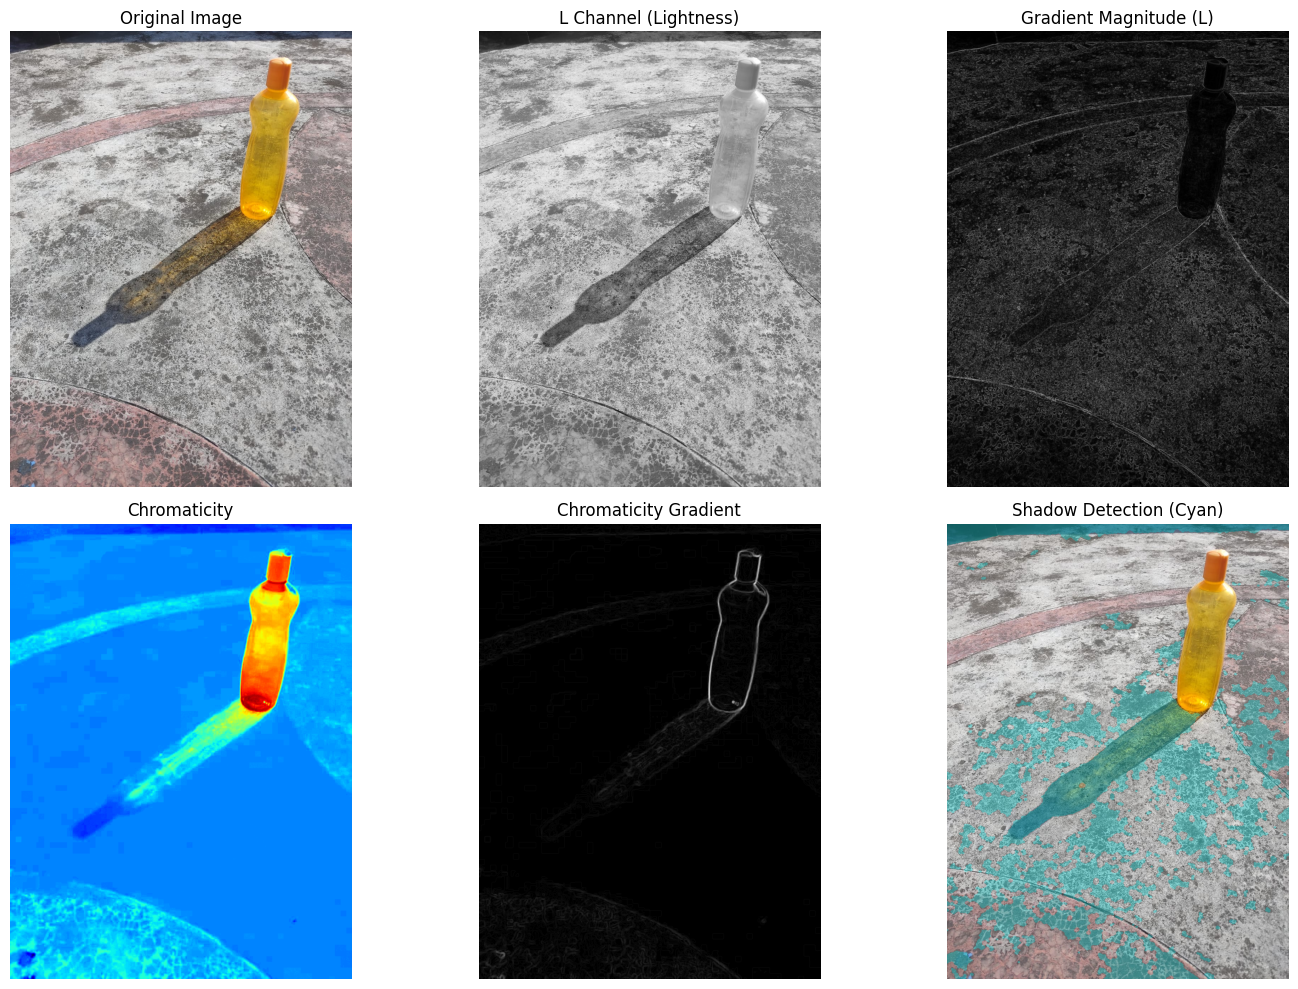

In [34]:
def shadow_detection_gradient(image_path):
    """
    Shadow detection using gradient analysis and illumination invariance.
    This method is particularly effective for shadows with clear boundaries.
    """
    
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Convert to LAB color space
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    # Step 1: Compute gradient magnitude on L channel
    # Shadows often have strong boundaries in the lightness channel
    sobelx = cv2.Sobel(l, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(l, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)
    gradient_magnitude = np.uint8(gradient_magnitude / gradient_magnitude.max() * 255)
    
    # Step 2: Compute chromaticity (a, b channels)
    # Shadows preserve chromaticity but reduce lightness
    chroma = np.sqrt(a.astype(np.float32)**2 + b.astype(np.float32)**2)
    chroma_norm = np.uint8(chroma / chroma.max() * 255)
    
    # Step 3: Create shadow candidates
    # Low lightness + low gradient in chromaticity = shadow
    _, l_dark = cv2.threshold(l, 100, 255, cv2.THRESH_BINARY_INV)
    
    # Compute gradient on chromaticity
    chroma_blur = cv2.GaussianBlur(chroma_norm, (5, 5), 0)
    chroma_grad_x = cv2.Sobel(chroma_blur, cv2.CV_64F, 1, 0, ksize=3)
    chroma_grad_y = cv2.Sobel(chroma_blur, cv2.CV_64F, 0, 1, ksize=3)
    chroma_gradient = np.sqrt(chroma_grad_x**2 + chroma_grad_y**2)
    chroma_gradient_norm = np.uint8(chroma_gradient / chroma_gradient.max() * 255)
    
    # Shadows have low chromaticity gradient
    _, low_chroma_grad = cv2.threshold(chroma_gradient_norm, 50, 255, cv2.THRESH_BINARY_INV)
    
    # Combine criteria
    shadow_mask = cv2.bitwise_and(l_dark, low_chroma_grad)
    
    # Morphological refinement
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    shadow_mask = cv2.morphologyEx(shadow_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    shadow_mask = cv2.morphologyEx(shadow_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(l, cmap='gray')
    axes[0, 1].set_title('L Channel (Lightness)')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(gradient_magnitude, cmap='gray')
    axes[0, 2].set_title('Gradient Magnitude (L)')
    axes[0, 2].axis('off')
    
    axes[1, 0].imshow(chroma_norm, cmap='jet')
    axes[1, 0].set_title('Chromaticity')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(chroma_gradient_norm, cmap='gray')
    axes[1, 1].set_title('Chromaticity Gradient')
    axes[1, 1].axis('off')
    
    # Final result overlay
    overlay = img_rgb.copy()
    overlay[shadow_mask == 255] = [0, 255, 255]  # Cyan for shadows
    result = cv2.addWeighted(img_rgb, 0.7, overlay, 0.3, 0)
    
    axes[1, 2].imshow(result)
    axes[1, 2].set_title('Shadow Detection (Cyan)')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return shadow_mask

# Run gradient-based detection
shadow_gradient = shadow_detection_gradient("./test35.jpg")

---

## 📊 Parameter Tuning Guidelines

### **Key Parameters and Their Effects:**

#### 1. **V-Channel Threshold (HSV Value)**
- **Range:** 0-255
- **Lower values (60-90):** More sensitive, detects lighter shadows
- **Higher values (100-130):** Less sensitive, only dark shadows
- **Recommended:** Start with 90-100

#### 2. **L-Channel Threshold (Lab Lightness)**
- **Range:** 0-255
- **Lower values (60-90):** More shadow candidates
- **Higher values (100-130):** Stricter shadow detection
- **Recommended:** Start with 90-100

#### 3. **Ratio Threshold**
- **Range:** 0-255
- **Higher values (180-200):** More sensitive to brightness changes
- **Lower values (150-170):** Conservative detection
- **Recommended:** Start with 180-190

#### 4. **Saturation Threshold (Object Detection)**
- **Range:** 0-255
- **Lower values (30-50):** Include more colorful regions as objects
- **Higher values (60-80):** Only highly saturated objects
- **Recommended:** Start with 40-50

#### 5. **Minimum Area Percentage**
- **Range:** 0.0001 - 0.01 (0.01% - 1% of image)
- **Smaller values:** Keep tiny shadow regions (more noise)
- **Larger values:** Filter out small shadows
- **Recommended:** Start with 0.0005 (0.05%)

#### 6. **Morphological Kernel Size**
- **Range:** 3, 5, 7, 9 (odd numbers)
- **Smaller (3-5):** Preserve details, keep noise
- **Larger (7-9):** Smoother shadows, lose detail
- **Recommended:** Start with 5-7

---

## 🎯 Limitations and Challenges

### **1. Lighting Conditions**
- **Problem:** Different light sources (sunlight, artificial light) affect shadow appearance
- **Solution:** Adjust thresholds based on lighting; use adaptive thresholding

### **2. Textured Surfaces**
- **Problem:** Shadows on textured surfaces can be mistaken for texture patterns
- **Solution:** Use morphological operations to smooth; increase minimum area threshold

### **3. Soft vs. Hard Shadows**
- **Problem:** Soft shadows (diffuse light) have gradual boundaries; hard shadows (point light) have sharp edges
- **Solution:** Adjust kernel size; use gradient-based methods for hard shadows

### **4. Colored Objects and Shadows**
- **Problem:** Highly saturated objects may be confused with shadows
- **Solution:** Use saturation thresholding to separate objects; combine HSV and Lab

### **5. Multiple Light Sources**
- **Problem:** Multiple overlapping shadows create complex patterns
- **Solution:** Use connected component analysis; apply region-based refinement

### **6. Shadow on Shadow**
- **Problem:** Overlapping shadows from multiple objects
- **Solution:** Difficult with classical methods; may need multi-scale analysis

---

## 🚀 Performance Improvements

### **Speed Optimizations:**
1. **Resize images** for faster processing: `cv2.resize(img, (width//2, height//2))`
2. **Use ROI (Region of Interest)** if shadows are in specific areas
3. **Optimize kernel sizes** - smaller kernels = faster processing
4. **Skip unnecessary color conversions**

### **Accuracy Improvements:**
1. **Combine multiple methods** (HSV + Lab + Ratio) for robustness
2. **Use temporal information** if processing video (shadows are consistent across frames)
3. **Apply local adaptive thresholding** instead of global
4. **Consider scene geometry** - shadows often appear near objects

### **When Classical Methods Fail:**
- **Very complex scenes** with many overlapping shadows
- **Challenging lighting** (e.g., HDR scenes, low light)
- **Shadows that don't follow typical properties** (e.g., colored shadows from stained glass)

In such cases, consider:
- **Deep learning approaches** (Semantic segmentation, Shadow-Net)
- **Physics-based illumination models**
- **Multi-view geometry** if multiple cameras available

---

## 📝 Quick Reference: Pseudocode Pipeline

```
ALGORITHM: Classical Shadow Detection

INPUT: RGB Image
OUTPUT: Binary Shadow Mask

1. PREPROCESSING
   - Load image
   - Convert RGB → HSV, RGB → Lab
   - Extract channels: H, S, V, L, a, b

2. OBJECT DETECTION (High-Contrast Regions)
   - Detect edges using Canny edge detector
   - Threshold saturation channel (S > threshold)
   - Apply adaptive thresholding on value channel
   - Combine masks: object_mask = edges OR saturation OR adaptive
   - Morphological closing and opening to clean up

3. SHADOW DETECTION (Multiple Criteria)
   a) Brightness-based:
      - Threshold V-channel: V < v_threshold
      - Threshold L-channel: L < l_threshold
   
   b) Ratio-based:
      - Compute gray = grayscale(image)
      - Compute blur = GaussianBlur(gray)
      - Compute ratio = gray / blur
      - Threshold ratio: ratio < ratio_threshold
   
   c) Combine:
      - shadow_mask = (V AND L) OR ratio
   
   d) Remove objects:
      - shadow_mask = shadow_mask AND NOT(object_mask)

4. POST-PROCESSING
   - Morphological opening (remove noise)
   - Morphological closing (fill gaps)
   - Connected component analysis
   - Filter by area: keep regions > min_area
   - Optional: Filter by shape, proximity to objects

5. OUTPUT
   - Return final shadow mask
   - Optionally overlay on original image
```

## 🔍 Summary and Trade-offs

### **Advantages of Classical Methods:**

✅ **No training data required** - Works immediately on new images  
✅ **Interpretable** - Each step has clear physical/mathematical meaning  
✅ **Fast** - Real-time processing possible on modern hardware  
✅ **Tunable** - Parameters can be adjusted for specific scenarios  
✅ **Lightweight** - No GPU or large model files needed  
✅ **Explainable** - Easy to debug and understand failures  

### **Disadvantages:**

❌ **Parameter sensitivity** - Requires tuning for different scenes  
❌ **Limited generalization** - May not work across diverse datasets  
❌ **Struggles with complexity** - Fails on overlapping shadows, complex textures  
❌ **Lighting dependency** - Performance varies with lighting conditions  
❌ **Heuristic-based** - Rules may not capture all shadow characteristics  
❌ **Manual feature engineering** - Cannot learn features from data  

### **Best Use Cases:**

1. **Controlled environments** - Indoor scenes, consistent lighting
2. **Simple scenes** - Few objects, clear shadows
3. **Real-time applications** - Where speed is critical
4. **Resource-constrained** - Embedded systems, mobile devices
5. **Prototyping** - Quick validation before deep learning
6. **Augmentation** - Combine with learned methods for hybrid approach

### **When to Consider Deep Learning:**

- Complex outdoor scenes with varying illumination
- Need for high accuracy across diverse datasets
- Abundant labeled training data available
- Computational resources (GPU) available
- Shadows with unusual properties (colored, overlapping)

---

## 💡 Tips for Best Results

1. **Start with default parameters**, then adjust incrementally
2. **Visualize intermediate steps** to understand pipeline behavior
3. **Test on multiple images** from your specific domain
4. **Combine multiple methods** - no single technique is perfect
5. **Use morphological operations** generously for noise removal
6. **Consider illumination conditions** when setting thresholds
7. **Validate with ground truth** if available
8. **Document parameter choices** for reproducibility

**Remember:** Shadow detection is challenging even for humans in ambiguous cases. Classical methods provide a strong baseline and can achieve excellent results in controlled scenarios!

---

## 🎨 High-Contrast Color Object Detection using Chromaticity Gradient

This method detects objects with strong color boundaries by analyzing the **chromaticity gradient** in the **a\*b\*** color space (Lab). Objects with high color contrast will have strong gradients in chromaticity, making their boundaries smooth and well-defined.

In [35]:
def detect_objects_chromaticity_gradient(image_path, 
                                         chroma_grad_threshold=30,
                                         sat_threshold=40,
                                         smoothing_kernel=5,
                                         morph_kernel=7,
                                         min_area_pixels=5000,
                                         visualize=True):
    """
    Detect high-contrast color objects using chromaticity gradient analysis.
    
    This method leverages the fact that objects with strong colors have high gradients
    in the chromaticity channels (a* and b* in Lab color space), resulting in smooth
    and accurate boundary detection.
    
    Parameters:
    -----------
    image_path : str
        Path to input image
    chroma_grad_threshold : int (0-255)
        Threshold for chromaticity gradient (lower = more sensitive, try 20-50)
    sat_threshold : int (0-255)
        Minimum saturation for color objects (lower = more objects, try 30-60)
    smoothing_kernel : int (odd number)
        Gaussian blur kernel size for smoothing gradients (3, 5, 7, 9)
    morph_kernel : int (odd number)
        Morphological operations kernel size (3, 5, 7, 9, 11)
    min_area_pixels : int
        Minimum object area in pixels (objects smaller than this will be filtered out)
        Default: 5000 pixels
    visualize : bool
        Show visualization of detection process
    
    Returns:
    --------
    object_mask : numpy array
        Binary mask of detected objects
    object_contours : list
        List of object contours
    stats : dict
        Detection statistics
    """
    
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image from {image_path}")
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width = img.shape[:2]
    
    # Convert to Lab color space
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    
    # Convert to HSV for saturation information
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h_channel, s_channel, v_channel = cv2.split(hsv)
    
    # ===== STEP 1: Compute Chromaticity Magnitude =====
    # Chromaticity in Lab space is represented by a* and b* channels
    # High chromaticity = colorful regions
    chroma_magnitude = np.sqrt(
        (a_channel.astype(np.float32) - 128)**2 + 
        (b_channel.astype(np.float32) - 128)**2
    )
    chroma_magnitude = np.uint8(chroma_magnitude / chroma_magnitude.max() * 255)
    
    # ===== STEP 2: Compute Chromaticity Gradient =====
    # Apply Gaussian blur for smooth gradients
    a_smooth = cv2.GaussianBlur(a_channel, (smoothing_kernel, smoothing_kernel), 0)
    b_smooth = cv2.GaussianBlur(b_channel, (smoothing_kernel, smoothing_kernel), 0)
    
    # Compute gradients in a* and b* channels using Sobel operator
    a_grad_x = cv2.Sobel(a_smooth, cv2.CV_64F, 1, 0, ksize=3)
    a_grad_y = cv2.Sobel(a_smooth, cv2.CV_64F, 0, 1, ksize=3)
    
    b_grad_x = cv2.Sobel(b_smooth, cv2.CV_64F, 1, 0, ksize=3)
    b_grad_y = cv2.Sobel(b_smooth, cv2.CV_64F, 0, 1, ksize=3)
    
    # Combined chromaticity gradient magnitude
    # This captures color boundaries (edges where color changes significantly)
    chroma_gradient = np.sqrt(
        a_grad_x**2 + a_grad_y**2 + b_grad_x**2 + b_grad_y**2
    )
    
    # Normalize to 0-255
    chroma_gradient_norm = np.uint8(
        (chroma_gradient / chroma_gradient.max() * 255)
    )
    
    # ===== STEP 3: Detect Object Boundaries =====
    # High chromaticity gradient indicates color boundaries
    _, chroma_edges = cv2.threshold(
        chroma_gradient_norm, 
        chroma_grad_threshold, 
        255, 
        cv2.THRESH_BINARY
    )
    
    # ===== STEP 4: Combine with Saturation =====
    # Objects with high color contrast typically have high saturation
    _, sat_mask = cv2.threshold(s_channel, sat_threshold, 255, cv2.THRESH_BINARY)
    
    # ===== STEP 5: Create Object Mask =====
    # Combine chromaticity edges with saturation information
    # Use morphological dilation to connect nearby edges
    kernel_dilate = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    chroma_edges_dilated = cv2.dilate(chroma_edges, kernel_dilate, iterations=2)
    
    # Combine: Areas with high saturation AND chromaticity boundaries
    object_mask = cv2.bitwise_and(sat_mask, chroma_edges_dilated)
    
    # Alternative: Use watershed-like approach - flood fill from chromaticity edges
    # This creates smooth object regions
    object_mask_filled = chroma_edges_dilated.copy()
    
    # ===== STEP 6: Morphological Refinement =====
    # Close gaps and smooth boundaries
    kernel_morph = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel, morph_kernel))
    object_mask_refined = cv2.morphologyEx(object_mask_filled, cv2.MORPH_CLOSE, kernel_morph, iterations=3)
    object_mask_refined = cv2.morphologyEx(object_mask_refined, cv2.MORPH_OPEN, kernel_morph, iterations=1)
    
    # Fill holes inside objects
    contours, _ = cv2.findContours(object_mask_refined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    object_mask_filled_final = np.zeros_like(object_mask_refined)
    cv2.drawContours(object_mask_filled_final, contours, -1, 255, thickness=cv2.FILLED)
    
    # ===== STEP 7: Filter by Area and Refine =====
    num_labels, labels, stats_cc, centroids = cv2.connectedComponentsWithStats(
        object_mask_filled_final, connectivity=8
    )
    
    min_object_area = min_area_pixels  # Use direct pixel count
    object_mask_final = np.zeros_like(object_mask_filled_final)
    
    object_regions = []
    removed_count = 0
    total_removed_pixels = 0
    
    for i in range(1, num_labels):  # Skip background
        area = stats_cc[i, cv2.CC_STAT_AREA]
        if area >= min_object_area:  # Changed to >= for consistency
            object_mask_final[labels == i] = 255
            
            # Extract individual object
            object_roi = (labels == i).astype(np.uint8) * 255
            obj_contours, _ = cv2.findContours(object_roi, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if obj_contours:
                # Calculate object height (bounding box height)
                obj_height = stats_cc[i, cv2.CC_STAT_HEIGHT]
                obj_width = stats_cc[i, cv2.CC_STAT_WIDTH]
                
                object_regions.append({
                    'label': i,
                    'area': int(area),
                    'centroid': centroids[i],
                    'bbox': (
                        stats_cc[i, cv2.CC_STAT_LEFT],
                        stats_cc[i, cv2.CC_STAT_TOP],
                        obj_width,
                        obj_height
                    ),
                    'height': obj_height,
                    'width': obj_width,
                    'aspect_ratio': obj_width / obj_height if obj_height > 0 else 0,
                    'contour': obj_contours[0]
                })
        else:
            removed_count += 1
            total_removed_pixels += area
    
    # Extract all contours for final mask
    object_contours, _ = cv2.findContours(object_mask_final, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Calculate statistics
    total_pixels = height * width
    object_pixels = np.sum(object_mask_final == 255)
    total_objects_before_filter = num_labels - 1  # Exclude background
    stats = {
        'total_pixels': total_pixels,
        'object_pixels': object_pixels,
        'object_percentage': (object_pixels / total_pixels) * 100,
        'num_objects': len(object_regions),
        'object_regions': object_regions,
        'min_area_pixels': min_area_pixels,
        'total_objects_before_filter': total_objects_before_filter,
        'removed_count': removed_count,
        'removed_pixels': total_removed_pixels
    }
    
    # ===== VISUALIZATION =====
    if visualize:
        fig, axes = plt.subplots(3, 3, figsize=(18, 16))
        
        # Row 1: Original and color channels
        axes[0, 0].imshow(img_rgb)
        axes[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
        axes[0, 0].axis('off')
        
        axes[0, 1].imshow(a_channel, cmap='RdYlGn')
        axes[0, 1].set_title('a* Channel (Green-Red)', fontsize=12)
        axes[0, 1].axis('off')
        
        axes[0, 2].imshow(b_channel, cmap='YlGnBu')
        axes[0, 2].set_title('b* Channel (Blue-Yellow)', fontsize=12)
        axes[0, 2].axis('off')
        
        # Row 2: Chromaticity analysis
        axes[1, 0].imshow(chroma_magnitude, cmap='hot')
        axes[1, 0].set_title('Chromaticity Magnitude', fontsize=12)
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(chroma_gradient_norm, cmap='gray')
        axes[1, 1].set_title('Chromaticity Gradient (Object Boundaries)', fontsize=12, fontweight='bold')
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(chroma_edges, cmap='gray')
        axes[1, 2].set_title(f'Gradient Edges (threshold={chroma_grad_threshold})', fontsize=12)
        axes[1, 2].axis('off')
        
        # Row 3: Object detection results
        axes[2, 0].imshow(sat_mask, cmap='gray')
        axes[2, 0].set_title(f'Saturation Mask (threshold={sat_threshold})', fontsize=12)
        axes[2, 0].axis('off')
        
        axes[2, 1].imshow(object_mask_final, cmap='gray')
        axes[2, 1].set_title(f'Detected Objects ({stats["num_objects"]} objects)', fontsize=12, fontweight='bold')
        axes[2, 1].axis('off')
        
        # Draw smooth contours on original image
        result_contours = img_rgb.copy()
        cv2.drawContours(result_contours, object_contours, -1, (0, 255, 0), 3)
        
        # Fill objects with semi-transparent color
        overlay = img_rgb.copy()
        for region in object_regions:
            color = np.random.randint(0, 255, 3).tolist()
            cv2.drawContours(overlay, [region['contour']], -1, color, -1)
        
        result_final = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)
        
        # Draw contours on top
        cv2.drawContours(result_final, object_contours, -1, (255, 255, 0), 2)
        
        # Add height labels on each object
        for idx, region in enumerate(object_regions, 1):
            x, y, w, h = region['bbox']
            # Draw height line on the right side of bounding box
            cv2.line(result_final, (x + w + 5, y), (x + w + 5, y + h), (255, 0, 255), 2)
            # Add height text
            cv2.putText(result_final, f"H:{h}px", 
                       (x + w + 10, y + h // 2), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 255), 2)
        
        axes[2, 2].imshow(result_final)
        axes[2, 2].set_title(f'Smooth Object Boundaries ({stats["object_percentage"]:.2f}%)', 
                            fontsize=12, fontweight='bold')
        axes[2, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Print detailed statistics
        print(f"\n{'='*60}")
        print(f"  HIGH-CONTRAST COLOR OBJECT DETECTION RESULTS")
        print(f"{'='*60}")
        print(f"Image size: {width} x {height} ({total_pixels:,} pixels)")
        print(f"Minimum area filter: {min_area_pixels:,} pixels")
        print(f"\nFiltering Results:")
        print(f"  Objects before filtering: {stats['total_objects_before_filter']}")
        print(f"  Objects after filtering: {stats['num_objects']} (kept)")
        print(f"  Objects removed: {stats['removed_count']} (< {min_area_pixels} pixels)")
        if stats['total_objects_before_filter'] > 0:
            print(f"  Removal rate: {stats['removed_count']/stats['total_objects_before_filter']*100:.1f}%")
        print(f"\nPixel Coverage:")
        print(f"  Total object area: {object_pixels:,} pixels ({stats['object_percentage']:.2f}%)")
        if stats['removed_pixels'] > 0:
            print(f"  Removed area: {stats['removed_pixels']:,} pixels")
        print(f"\nIndividual Objects (≥ {min_area_pixels} pixels):")
        print(f"{'-'*60}")
        for idx, obj in enumerate(object_regions, 1):
            x, y, w, h = obj['bbox']
            cx, cy = obj['centroid']
            print(f"  Object {idx}:")
            print(f"    Area: {obj['area']:,} pixels ({obj['area']/total_pixels*100:.2f}%)")
            print(f"    Height: {obj['height']} pixels")
            print(f"    Width: {obj['width']} pixels")
            print(f"    Aspect Ratio (W:H): {obj['aspect_ratio']:.2f}")
            print(f"    Bounding Box: ({x}, {y}, {w}, {h})")
            print(f"    Centroid: ({cx:.1f}, {cy:.1f})")
            print(f"    Contour Points: {len(obj['contour'])}")
        print(f"{'='*60}\n")
    
    return object_mask_final, object_contours, stats

## 🚀 Run Object Detection with Chromaticity Gradient

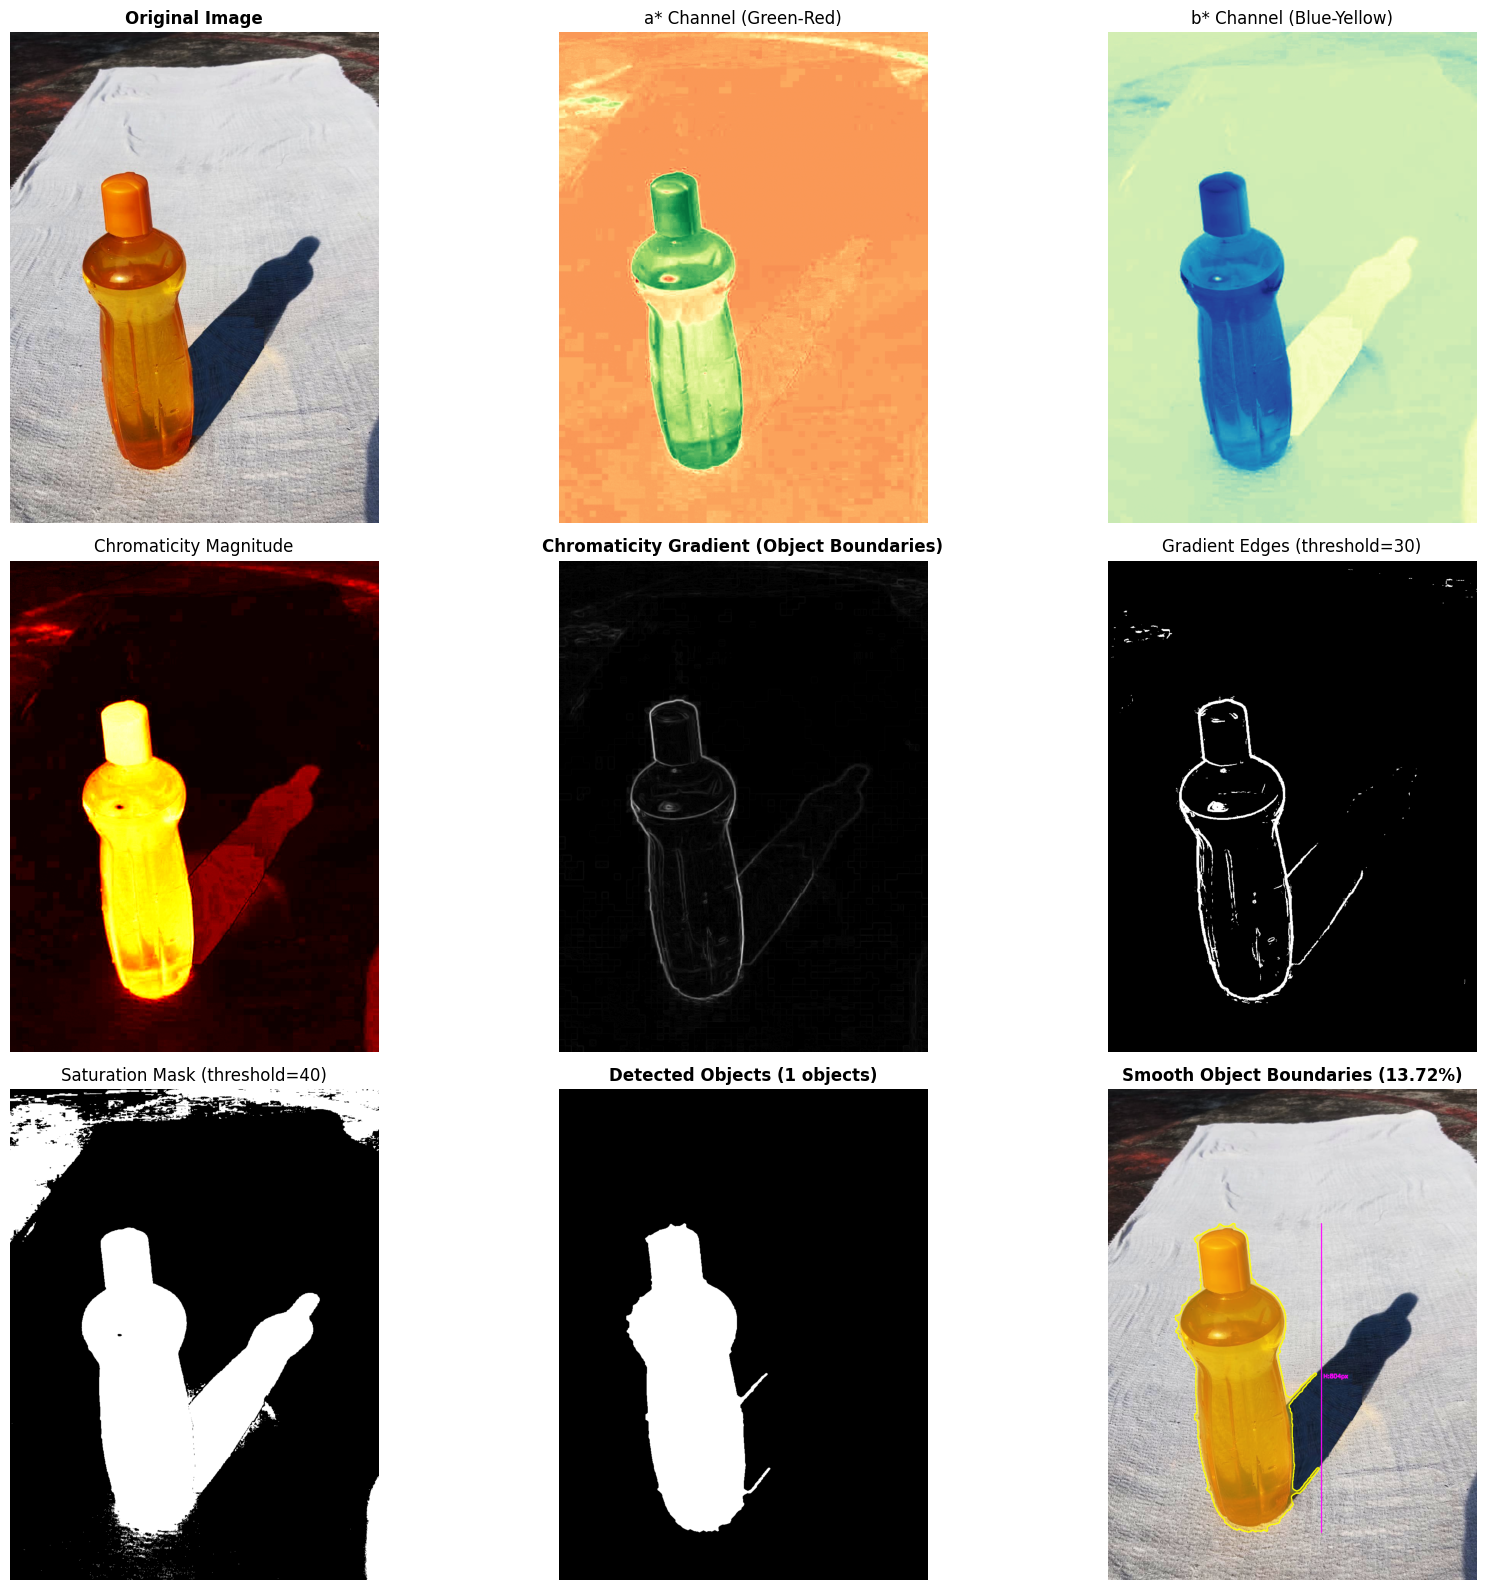


  HIGH-CONTRAST COLOR OBJECT DETECTION RESULTS
Image size: 960 x 1280 (1,228,800 pixels)
Minimum area filter: 5,000 pixels

Filtering Results:
  Objects before filtering: 11
  Objects after filtering: 1 (kept)
  Objects removed: 10 (< 5000 pixels)
  Removal rate: 90.9%

Pixel Coverage:
  Total object area: 168,604 pixels (13.72%)
  Removed area: 5,985 pixels

Individual Objects (≥ 5000 pixels):
------------------------------------------------------------
  Object 1:
    Area: 168,604 pixels (13.72%)
    Height: 804 pixels
    Width: 375 pixels
    Aspect Ratio (W:H): 0.47
    Bounding Box: (175, 352, 375, 804)
    Centroid: (342.9, 773.0)
    Contour Points: 807



In [36]:
# Detect high-contrast color objects with smooth boundaries
# Filter: Only keep objects with 5000 or more pixels

object_mask, contours, stats = detect_objects_chromaticity_gradient(
    "./new.jpg",
    chroma_grad_threshold=30,    # Lower = more sensitive to color changes (try 20-50)
    sat_threshold=40,            # Lower = include more colored regions (try 30-60)
    smoothing_kernel=5,          # Larger = smoother gradients (3, 5, 7, 9)
    morph_kernel=7,              # Larger = smoother object boundaries (5, 7, 9, 11)
    min_area_pixels=5000,        # Minimum object size in pixels (change this value as needed)
    visualize=True
)